In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("E:\\MASTERS\\Machine learning\\Assignment1\\Cars.csv")

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [3]:
#Checking dimensions 
df.shape

(8128, 13)

In [4]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [6]:
#Missing values, quantifies missingness per column
df.isna().sum().sort_values(ascending=False)

torque           222
mileage          221
engine           221
seats            221
max_power        215
name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
dtype: int64

In [7]:
#brief statistics for the numerical columns
df.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


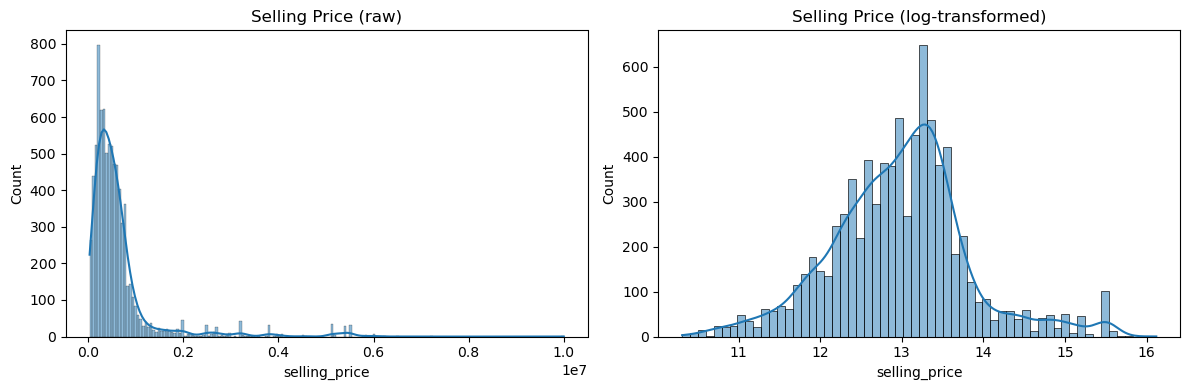

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['selling_price'], kde=True, ax=axes[0])
axes[0].set_title('Selling Price (raw)')

sns.histplot(np.log(df['selling_price']), kde=True, ax=axes[1])
axes[1].set_title('Selling Price (log-transformed)')

plt.tight_layout()
plt.show()

In [9]:
missing_cols = ['mileage', 'engine', 'max_power', 'torque', 'seats']
df[missing_cols].isna().sum(axis=1).value_counts().sort_index()

0    7906
1       1
4       6
5     215
Name: count, dtype: int64

In [10]:
#Investigating Categorical variables
df['fuel'].value_counts()

fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: count, dtype: int64

In [11]:
df['owner'].value_counts()

owner
First Owner             5289
Second Owner            2105
Third Owner              555
Fourth & Above Owner     174
Test Drive Car             5
Name: count, dtype: int64

In [12]:
df['seller_type'].value_counts()
df['transmission'].value_counts()

transmission
Manual       7078
Automatic    1050
Name: count, dtype: int64

In [13]:
#Checking unique values
df['fuel'].unique()
df['owner'].unique()


array(['First Owner', 'Second Owner', 'Third Owner',
       'Fourth & Above Owner', 'Test Drive Car'], dtype=object)

In [16]:
df['selling_price'].describe()


count    8.128000e+03
mean     6.382718e+05
std      8.062534e+05
min      2.999900e+04
25%      2.549990e+05
50%      4.500000e+05
75%      6.750000e+05
max      1.000000e+07
Name: selling_price, dtype: float64

In [17]:
df['selling_price'].min(), df['selling_price'].max()
df['selling_price'].median()

450000.0

In [18]:
df[['year', 'selling_price', 'km_driven', 'seats']].describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [19]:
df[['mileage', 'engine', 'max_power']].head(10)

,mileage,engine,max_power
0,23.4 kmpl,1248 CC,74 bhp
1,21.14 kmpl,1498 CC,103.52 bhp
2,17.7 kmpl,1497 CC,78 bhp
3,23.0 kmpl,1396 CC,90 bhp
4,16.1 kmpl,1298 CC,88.2 bhp
5,20.14 kmpl,1197 CC,81.86 bhp
6,17.3 km/kg,1061 CC,57.5 bhp
7,16.1 kmpl,796 CC,37 bhp
8,23.59 kmpl,1364 CC,67.1 bhp
9,20.0 kmpl,1399 CC,68.1 bhp


In [31]:
# Reload the original dataset
df = pd.read_csv("Cars.csv")

# Remove CNG and LPG cars
df = df[~df['fuel'].isin(['CNG', 'LPG'])]

# Remove Test Drive Cars
df = df[df['owner'] != 'Test Drive Car']

# Convert owner categories into numerical values
owner_mapping = {
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
    'Test Drive Car': 5
}

df['owner'] = df['owner'].map(owner_mapping)

# Clean mileage
df['mileage'] = df['mileage'].str.split().str[0].astype(float)

# Clean engine
df['engine'] = df['engine'].str.split().str[0].astype(float)

# Clean max_power
df['max_power'] = df['max_power'].str.split().str[0].astype(float)

# Display the owner counts
df['owner'].value_counts()

owner
1    5238
2    2073
3     547
4     170
Name: count, dtype: int64

In [32]:
df.shape

(8028, 13)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8028 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8028 non-null   object 
 1   year           8028 non-null   int64  
 2   selling_price  8028 non-null   int64  
 3   km_driven      8028 non-null   int64  
 4   fuel           8028 non-null   object 
 5   seller_type    8028 non-null   object 
 6   transmission   8028 non-null   object 
 7   owner          8028 non-null   int64  
 8   mileage        7814 non-null   float64
 9   engine         7814 non-null   float64
 10  max_power      7820 non-null   float64
 11  torque         7814 non-null   object 
 12  seats          7814 non-null   float64
dtypes: float64(4), int64(4), object(5)
memory usage: 878.1+ KB


In [34]:
# Extract the car brand from the first word of the name
df['brand'] = df['name'].str.split().str[0]

df[['name', 'brand']].head()

,name,brand
0,Maruti Swift Dzire VDI,Maruti
1,Skoda Rapid 1.5 TDI Ambition,Skoda
2,Honda City 2017-2020 EXi,Honda
3,Hyundai i20 Sportz Diesel,Hyundai
4,Maruti Swift VXI BSIII,Maruti


In [35]:
# Drop the original name and torque columns
df = df.drop(columns=['name', 'torque'])

df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand
0,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0,Maruti
1,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0,Skoda
2,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0,Honda
3,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0,Hyundai
4,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0,Maruti


In [36]:
#Checking the missing values again
df.isnull().sum()

year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          214
engine           214
max_power        208
seats            214
brand              0
dtype: int64

In [37]:
# Remove rows with missing values
df = df.dropna()

# Reset the index after removing rows
df = df.reset_index(drop=True)

df.shape

(7814, 12)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7814 entries, 0 to 7813
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           7814 non-null   int64  
 1   selling_price  7814 non-null   int64  
 2   km_driven      7814 non-null   int64  
 3   fuel           7814 non-null   object 
 4   seller_type    7814 non-null   object 
 5   transmission   7814 non-null   object 
 6   owner          7814 non-null   int64  
 7   mileage        7814 non-null   float64
 8   engine         7814 non-null   float64
 9   max_power      7814 non-null   float64
 10  seats          7814 non-null   float64
 11  brand          7814 non-null   object 
dtypes: float64(4), int64(4), object(4)
memory usage: 732.7+ KB


In [39]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand
0,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0,Maruti
1,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0,Skoda
2,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0,Honda
3,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0,Hyundai
4,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0,Maruti


In [40]:
df.isnull().sum()

year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
brand            0
dtype: int64

Distribution of selling price

In [42]:
df['selling_price'].describe()

count    7.814000e+03
mean     6.515864e+05
std      8.097971e+05
min      2.999900e+04
25%      2.700000e+05
50%      4.550000e+05
75%      6.950000e+05
max      1.000000e+07
Name: selling_price, dtype: float64

Correlation among numerical features

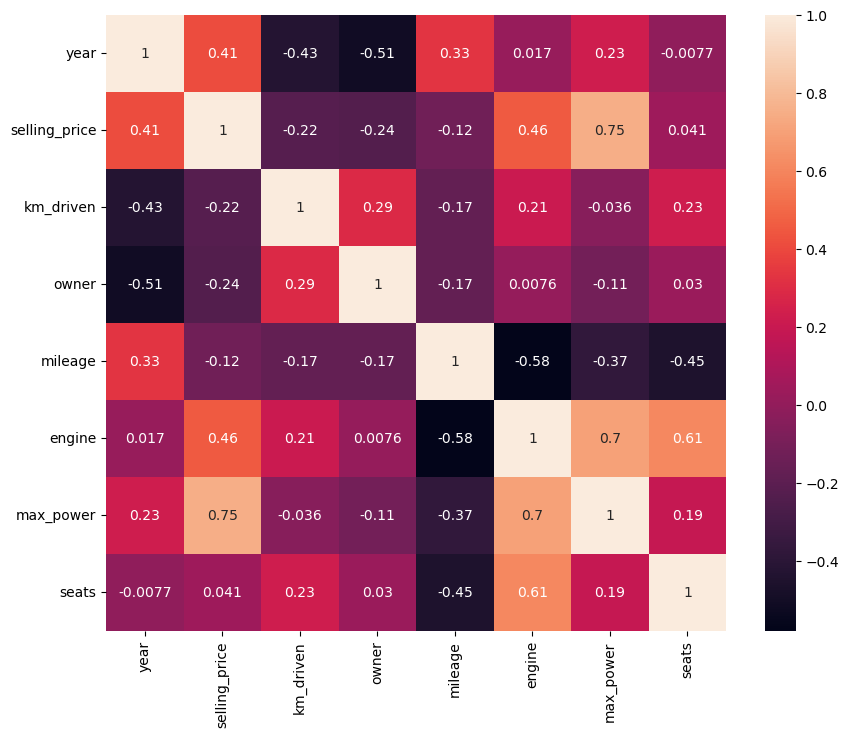

In [43]:
numeric_cols = [
    'year',
    'selling_price',
    'km_driven',
    'owner',
    'mileage',
    'engine',
    'max_power',
    'seats'
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True)
plt.show()

In [44]:
X = df.drop('selling_price', axis=1)
y = np.log(df['selling_price'])

In [45]:
y = np.log(df['selling_price'])

In [46]:
X = pd.get_dummies(
    X,
    columns=['fuel', 'seller_type', 'transmission', 'brand'],
    drop_first=True
)

X.head()

,year,km_driven,owner,mileage,engine,max_power,seats,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,...,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_Opel,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,2014,145500,1,23.40,1248.0,74.00,5.0,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,2014,120000,2,21.14,1498.0,103.52,5.0,False,True,False,...,False,False,False,False,False,True,False,False,False,False
2,2006,140000,3,17.70,1497.0,78.00,5.0,True,True,False,...,False,False,False,False,False,False,False,False,False,False
3,2010,127000,1,23.00,1396.0,90.00,5.0,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,2007,120000,1,16.10,1298.0,88.20,5.0,True,True,False,...,False,False,False,False,False,False,False,False,False,False


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(6251, 41)
(1563, 41)


In [48]:
X_train.shape
X_test.shape

(1563, 41)

In [49]:
print(y.head())
print(y.shape)

0    13.017003
1    12.821258
2    11.970350
3    12.323856
4    11.775290
Name: selling_price, dtype: float64
(7814,)


Evaluating different models and see the results

In [ ]:
#Linear Regression
from sklearn.linear_model import LinearRegression

In [51]:
linear_model = LinearRegression()

In [52]:
linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [53]:
y_pred_log = linear_model.predict(X_test)

In [54]:
y_pred = np.exp(y_pred_log)

In [55]:
y_test_original = np.exp(y_test)

In [56]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²   :", r2)

MAE : 113254.010364819
MSE : 58090971378.02865
RMSE: 241020.6866184491
R²   : 0.9141568736447485


In [ ]:
#Decision Tree Model
from sklearn.tree import DecisionTreeRegressor

In [58]:
tree_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

In [59]:
tree_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [60]:
y_pred_log_tree = tree_model.predict(X_test)

In [61]:
y_pred_tree = np.exp(y_pred_log_tree)

In [62]:
mae_tree = mean_absolute_error(y_test_original, y_pred_tree)
mse_tree = mean_squared_error(y_test_original, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test_original, y_pred_tree)

print("Decision Tree Results")
print("MAE :", mae_tree)
print("MSE :", mse_tree)
print("RMSE:", rmse_tree)
print("R²  :", r2_tree)

Decision Tree Results
MAE : 79405.40416936688
MSE : 22217566518.08924
RMSE: 149055.58197561486
R²  : 0.9671682995709054


In [63]:
#Random Forest model
from sklearn.ensemble import RandomForestRegressor

In [64]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

In [65]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [66]:
y_pred_log_rf = rf_model.predict(X_test)

In [67]:
y_pred_rf = np.exp(y_pred_log_rf)

In [68]:
mae_rf = mean_absolute_error(y_test_original, y_pred_rf)
mse_rf = mean_squared_error(y_test_original, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test_original, y_pred_rf)

print("Random Forest Results")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
MAE : 72867.36313000724
MSE : 18894189748.35765
RMSE: 137456.13754342747
R²  : 0.9720793734469757


Feature Importance

In [69]:
# Get feature importance from the Random Forest model
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(15)

max_power                 0.464352
year                      0.429305
engine                    0.043475
km_driven                 0.013584
mileage                   0.011879
brand_Tata                0.008629
seats                     0.006574
brand_Toyota              0.003918
brand_Chevrolet           0.003729
owner                     0.002984
fuel_Petrol               0.002665
transmission_Manual       0.001112
brand_Maruti              0.001111
brand_Mahindra            0.001032
seller_type_Individual    0.001017
dtype: float64

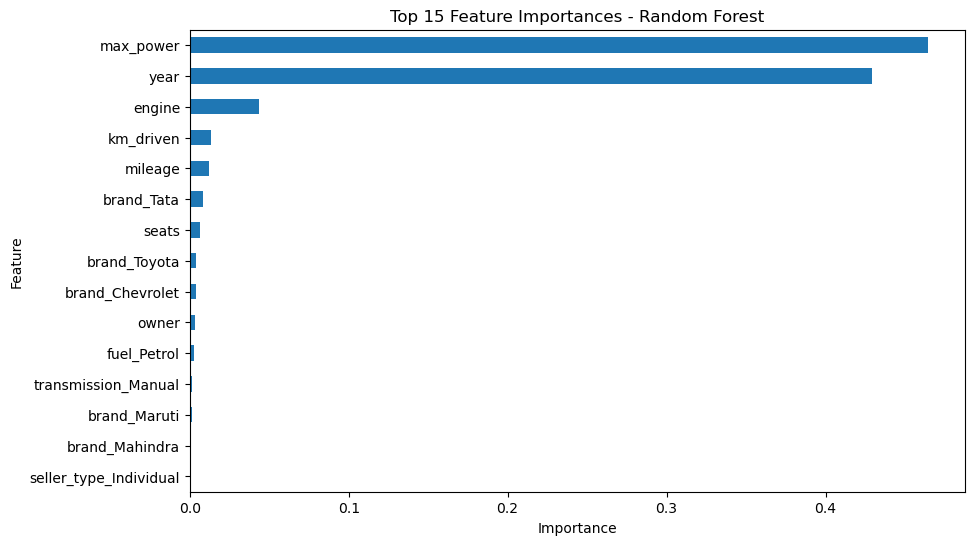

In [70]:
plt.figure(figsize=(10, 6))

feature_importance.head(15).sort_values().plot(kind='barh')

plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

In [71]:
feature_importance.head(15)

max_power                 0.464352
year                      0.429305
engine                    0.043475
km_driven                 0.013584
mileage                   0.011879
brand_Tata                0.008629
seats                     0.006574
brand_Toyota              0.003918
brand_Chevrolet           0.003729
owner                     0.002984
fuel_Petrol               0.002665
transmission_Manual       0.001112
brand_Maruti              0.001111
brand_Mahindra            0.001032
seller_type_Individual    0.001017
dtype: float64

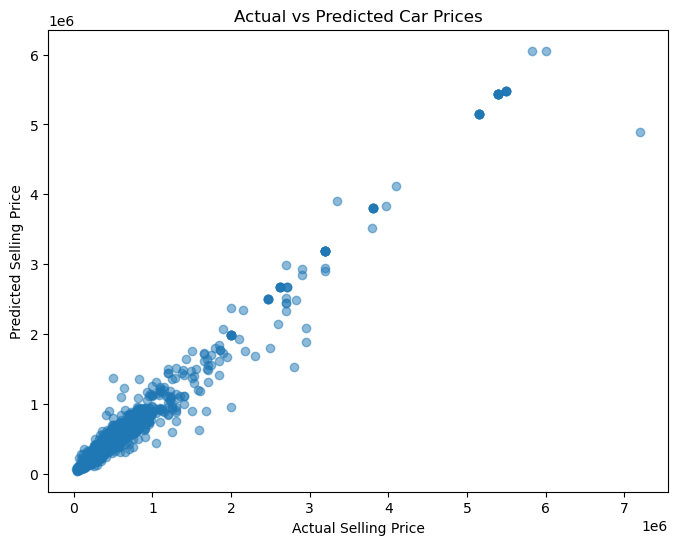

In [72]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test_original, y_pred_rf, alpha=0.5)

plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Car Prices')

plt.show()

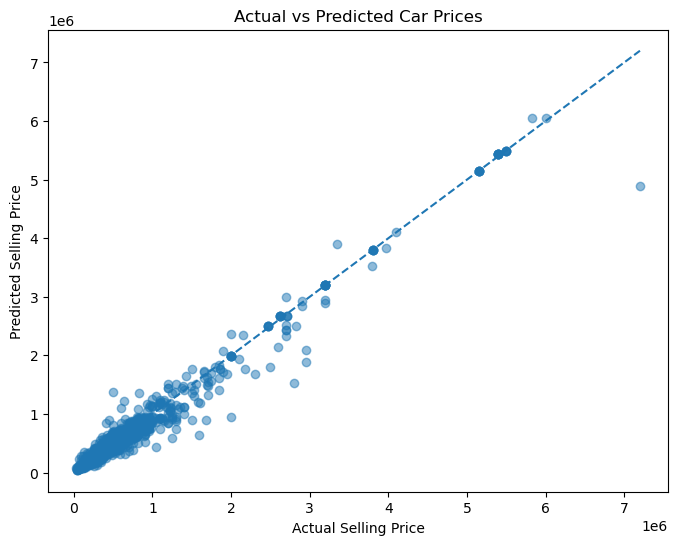

In [73]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test_original, y_pred_rf, alpha=0.5)

plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()],
    linestyle='--'
)

plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Car Prices')

plt.show()

In [74]:
residuals = y_test_original - y_pred_rf

print(residuals.describe())

count    1.563000e+03
mean     1.495028e+04
std      1.366844e+05
min     -8.749114e+05
25%     -3.789575e+04
50%      1.454869e+03
75%      4.944415e+04
max      2.307460e+06
Name: selling_price, dtype: float64


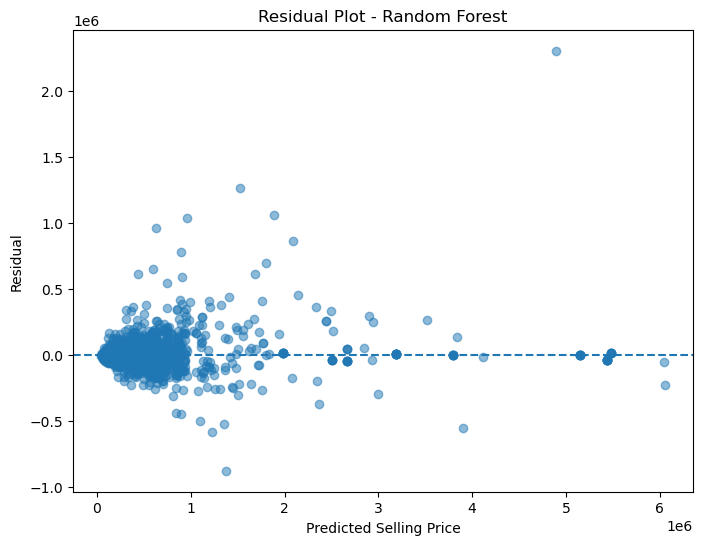

In [75]:
plt.figure(figsize=(8, 6))

plt.scatter(y_pred_rf, residuals, alpha=0.5)

plt.axhline(0, linestyle='--')

plt.xlabel('Predicted Selling Price')
plt.ylabel('Residual')
plt.title('Residual Plot - Random Forest')

plt.show()

In [76]:
from sklearn.model_selection import GridSearchCV

In [77]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_leaf': [1, 2]
}

In [78]:
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

In [79]:
rf_grid.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [10, 15, ...], 'min_samples_leaf': [1, 2], 'n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [80]:
print("Best Parameters:")
print(rf_grid.best_params_)

print("\nBest CV R²:")
print(rf_grid.best_score_)

Best Parameters:
{'max_depth': 15, 'min_samples_leaf': 1, 'n_estimators': 200}

Best CV R²:
0.9363013838518811


In [81]:
best_rf = rf_grid.best_estimator_

In [82]:
y_pred_log_best = best_rf.predict(X_test)

In [83]:
y_pred_best = np.exp(y_pred_log_best)

In [84]:
mae_best = mean_absolute_error(y_test_original, y_pred_best)
mse_best = mean_squared_error(y_test_original, y_pred_best)
rmse_best = np.sqrt(mse_best)
r2_best = r2_score(y_test_original, y_pred_best)

print("Tuned Random Forest Results")
print("MAE :", mae_best)
print("MSE :", mse_best)
print("RMSE:", rmse_best)
print("R²  :", r2_best)

Tuned Random Forest Results
MAE : 63763.01957579102
MSE : 16175503336.265133
RMSE: 127182.95222342157
R²  : 0.9760968745432275


Note : The tuned Random forest improves on the original Random Forest in every metric 

In [85]:
# Feature importance from the tuned Random Forest
final_importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

final_importance.head(15)

max_power                 0.450248
year                      0.421349
engine                    0.045419
km_driven                 0.022594
mileage                   0.016783
brand_Tata                0.008509
seats                     0.007199
owner                     0.005634
brand_Toyota              0.004145
brand_Chevrolet           0.003667
fuel_Petrol               0.002734
brand_Maruti              0.001543
seller_type_Individual    0.001463
transmission_Manual       0.001440
brand_Mahindra            0.001298
dtype: float64

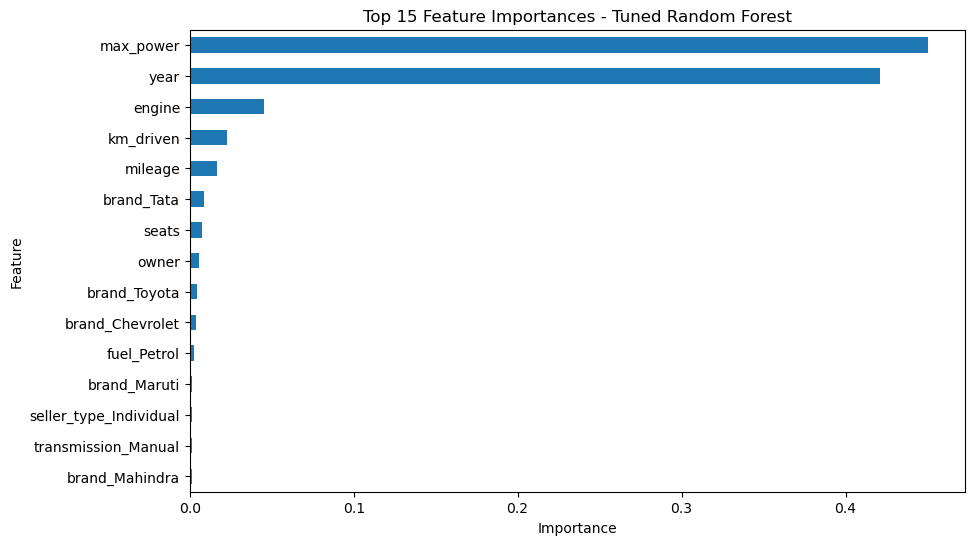

In [86]:
plt.figure(figsize=(10, 6))

final_importance.head(15).sort_values().plot(kind='barh')

plt.title('Top 15 Feature Importances - Tuned Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

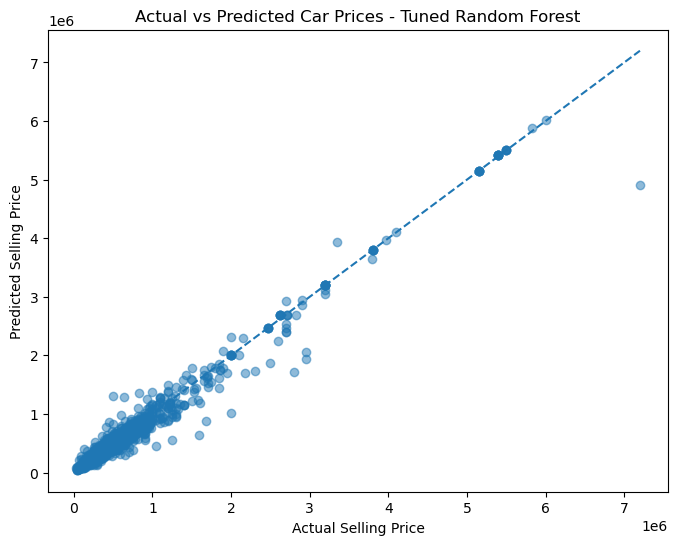

In [87]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test_original, y_pred_best, alpha=0.5)

plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()],
    linestyle='--'
)

plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Car Prices - Tuned Random Forest')

plt.show()

In [90]:
import joblib

joblib.dump(best_rf, 'car_price_model.pkl')
joblib.dump(X_train.columns.tolist(), 'model_features.pkl')

['model_features.pkl']

## Inference on a New Car

To test the final tuned Random Forest model, we will predict the selling price of a hypothetical car using the following features:

- Year: 2018
- KM Driven: 50,000 km
- Fuel: Petrol
- Seller Type: Individual
- Transmission: Manual
- Owner: First Owner
- Mileage: 20.0 kmpl
- Engine: 1197 CC
- Max Power: 82 bhp
- Seats: 5
- Brand: Maruti

In [91]:
new_car = pd.DataFrame({
    'year': [2018],
    'km_driven': [50000],
    'fuel': ['Petrol'],
    'seller_type': ['Individual'],
    'transmission': ['Manual'],
    'owner': [1],
    'mileage': [20.0],
    'engine': [1197],
    'max_power': [82.0],
    'seats': [5],
    'brand': ['Maruti']
})

new_car

,year,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand
0,2018,50000,Petrol,Individual,Manual,1,20.0,1197,82.0,5,Maruti


In [92]:
#One hot encode it
new_car_encoded = pd.get_dummies(
    new_car,
    columns=['fuel', 'seller_type', 'transmission', 'brand'],
    drop_first=True
)

In [93]:
new_car_encoded = new_car_encoded.reindex(
    columns=X_train.columns,
    fill_value=0
)

In [94]:
new_car_encoded.shape

(1, 41)

In [95]:
new_car_log_prediction = best_rf.predict(new_car_encoded)

new_car_price = np.exp(new_car_log_prediction[0])

print("Predicted Selling Price:", new_car_price)

Predicted Selling Price: 565945.4481794817


In [96]:
print(f"Predicted Selling Price: ₹{new_car_price:,.2f}")

Predicted Selling Price: ₹565,945.45


## Task 2: Report and Analysis

It can be seen that there are some car attributes which have significantly greater impact on selling price than others. It follows from the feature importance analysis of the tuned Random Forest model where the most important attribute is max_power with the importance of approximately 0.464, whereas the second most important is year with the importance of approximately 0.429. The contribution of the above-mentioned attributes to the feature importance of the model is very large. The third most important feature is engine which importance is approximately 0.043, whereas importance of the km_driven and mileage are significantly lower. Among the categorical features, brand_Tata has the greatest importance of the one-hot encoded features shown, however, it is significantly lower than the importance of max_power and year. Transmission, seller_type, and many brand categories individually have the importance close to zero. It means that the model uses the attributes that characterize the car's power, age and engine mostly when predicting its selling price. Some low importance of the categorical attributes does not necessarily mean that the whole categorical attribute has no impact because categorical attributes were split into many one-hot encoded attributes.
Four regression algorithms/versions were evaluated during the experiments. Linear Regression performed the worst, with an R² of 0.9142, MAE of approximately 113,254, and RMSE of approximately 241,021. The Decision Tree performed considerably better, achieving an R² of 0.9672. The Random Forest further improved the results, with an R² of 0.9721 and RMSE of approximately 137,456. Finally, tuning the Random Forest improved its performance further. The tuned Random Forest, using 200 trees, a maximum depth of 15, and a minimum samples leaf of 1, achieved the best test performance with an R² of 0.9761, MAE of approximately 63,763, and RMSE of approximately 127,183. This indicates that the tuned Random Forest was the best-performing model among those tested. Its stronger performance compared with Linear Regression suggests that the relationship between the car characteristics and selling price is not simply linear, while the use of multiple decision trees allows the Random Forest to model more complex relationships in the data. The actual-versus-predicted plot also shows that most predictions are close to the diagonal reference line, although some larger errors remain, particularly for higher-priced cars.

Overall, the tuned Random Forest provides a strong model for predicting car selling prices in this dataset. Its R² value of 0.9761 indicates that it explains most of the variation in the test-set prices. However, the residual analysis shows that some cars have relatively large prediction errors, so the model is not equally accurate for every vehicle. The final inference experiment also demonstrated that the trained model can be used to estimate the price of a new car after applying the same preprocessing and one-hot encoding used during training. For the example car used in the inference experiment, the model predicted a selling price of approximately ₹565,945.